# 09 — Due diligence: is dz/vxy spread a usable cosmic veto?

A proposal on the table (collaborator's) is to veto cosmic rays using the internal
**dz/vxy spread** of a lepton-jet's muons — the max−min of the muons' longitudinal
impact parameter dz and of vxy (their transverse reference position) — **alongside** a
cos alpha (back-to-back opening angle) veto, on the intuition that a cosmic ray's two legs
are spatially incoherent. This note does the due diligence, using a fuller signal-MC grid
(15 files/sample across mass × cτ, both channels) through the current processor, plus the
2018A data cosmic CR.

**The intuition is sound; the *raw threshold* form is not.** Findings, separated by how
spread would be used:

1. **As a standalone veto — no.** A raw dz/vxy-spread threshold removes ~6–10% of signal
   even at prompt cτ and 50 / 75 / 90% at cτ ≈ 2 / 19 / 80 mm, because a displaced
   dark-photon LJ genuinely has large internal spread (and at those cτ the muons are
   DSA-dominated, adding resolution smearing). cos alpha < −0.98 costs ~0% everywhere.
2. **As an addition alongside cos alpha — not yet decidable, plausibly complementary.**
   cos alpha has a real blind spot (its partner pool excludes the two signal LJs, so a
   cosmic whose second leg isn't separately reconstructed gives min cos α = 1 and is
   missed); spread could fire there. Our cosmic CR is *defined by* cos alpha, so it cannot
   test this — it can only show that spread tags a *subset* of the cosmics cos alpha
   already catches. Deciding this needs an **independently-tagged** cosmic sample.
3. **The constructive path.** The incoherence intuition maps not onto a raw max−min
   threshold (which displaced signal also trips) but onto a **vertex-consistency** variable
   (a common-vertex χ² or the 2D dz–vxy correlation) tested on an independent cosmic
   sample — that is where this should go next.

In [1]:
import os, subprocess, sys, glob
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from coffea.util import load
sys.path.insert(0, os.getcwd())
import abcd_tools as at
hep.style.use("CMS"); plt.rcParams["figure.figsize"] = (9, 7)

# Fuller signal-MC grid through the CURRENT processor (vxyspread + corrected cos-alpha),
# 15 files/sample across mass x ctau, both channels.
GRID = "/uscms_data/d3/murtazas/mc_grid/out"
DATA_CR = "/store/group/lpcmetx/SIDM/coffea_outputs/murtazas/abcd_cosmic_2018A"
WD = "/uscms_data/d3/murtazas/abcd_cosmic_local"; os.makedirs(WD, exist_ok=True)
FIXED_MASS = "500GeV_1p2GeV"   # the clean fixed-mass ctau series (0.019/1.9/19 mm)

def load_s(f):
    o = load(f); o = o["out"] if isinstance(o, dict) and "out" in o else o
    return o[list(o)[0]]

def ctau_mm(s):
    return float(s.split("_")[-1].replace("mm", "").replace("p", "."))

def cosmic3d(o, ch2):
    h = o["hists"]["abcd_cosmic_2mu2e" if ch2 == "2mu2e" else "abcd_cosmic_4mu"]
    base = [c for c in list([a for a in h.axes if a.name == "channel"][0]) if "cosmic" not in c][0]
    cn, dn, vn = ("mincosa", "dzspread", "vxyspread") if ch2 == "2mu2e" else ("mincosa0", "dzspread0", "vxyspread0")
    red = {"channel": base}
    for a in h.axes:
        if a.name not in ("channel", cn, dn, vn):
            red[a.name] = sum
    hc = h[red]; names = [a.name for a in hc.axes]
    val = np.transpose(hc.view()["value"], [names.index(cn), names.index(dn), names.index(vn)])
    return val, np.asarray(hc.axes[cn].edges), np.asarray(hc.axes[dn].edges), np.asarray(hc.axes[vn].edges)

def spread_cost(val, ce, de, ve, D):
    # PURE dz-OR-vxy spread veto (keep ALL cos-alpha): kept = dz<D AND vxy<D
    idz, ivx = int(np.argmin(np.abs(de - D))), int(np.argmin(np.abs(ve - D)))
    tot = val.sum(); kept = val[:, :idz, :ivx].sum()
    return 1 - kept / tot if tot > 0 else np.nan

def cosa_cost(val, ce, de, ve, C=-0.98):
    ic = int(np.argmin(np.abs(ce - C)))
    tot = val.sum(); kept = val[ic:, :, :].sum()
    return 1 - kept / tot if tot > 0 else np.nan

SAMPLES = sorted(glob.glob(GRID + "/*.coffea"))
print(f"loaded {len(SAMPLES)} signal MC samples across mass x ctau")

loaded 12 signal MC samples across mass x ctau


## 1. Standalone spread veto: the signal cost (decisive against a raw threshold)

For each signal, the fraction removed by a **pure** dz/vxy-spread veto (keeping all
cos alpha) at 0.5 / 5 / 10 cm, and by cos alpha < −0.98, versus cτ.

**How to read it.** Log–log; solid line + filled markers = the clean fixed-mass
500 GeV/1.2 GeV cτ scan (0.019 / 1.9 / 19 mm); open markers = the other masses across the
grid; the gray line is 1%. A usable veto stays near 1% for *all* signals.

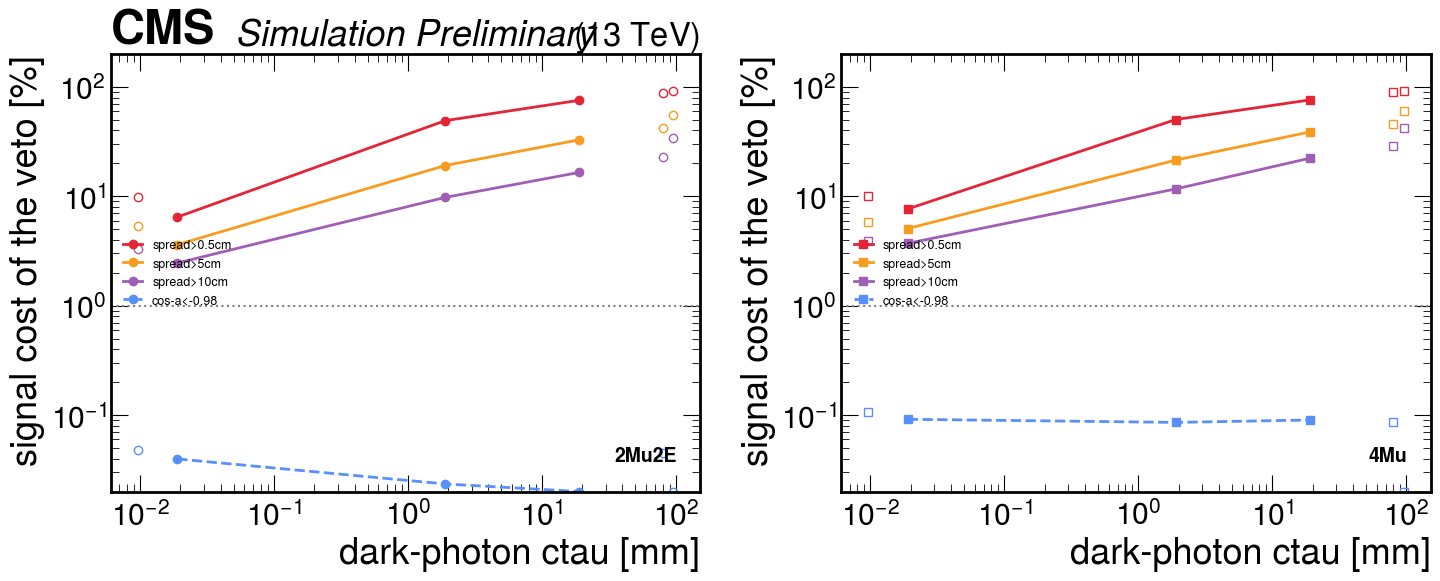

Filled = fixed-mass 500GeV/1.2GeV scan (cleanly rising); open = other masses.
The cost is monotonic in LAB displacement (betagamma*ctau), not proper ctau -- the
open 1000GeV/0.0096mm point sits ABOVE 500GeV/0.019mm despite a shorter proper ctau.


In [2]:
# Section 1: cost of a PURE dz/vxy-spread veto (keep all cos-alpha) vs ctau, and
# cos-alpha<-0.98, both channels. The 500GeV/1.2GeV series (filled markers, solid line)
# is the CLEAN fixed-mass ctau scan; other masses (open markers) span the grid.
fig, axs = plt.subplots(1, 2, figsize=(15, 6.4))
for ax, chan, mk in zip(axs, ["2Mu2E", "4Mu"], ["o", "s"]):
    ss = sorted([s for s in SAMPLES if "/" + chan in "/" + os.path.basename(s)],
                key=lambda s: ctau_mm(os.path.basename(s)[:-7]))
    for D, col, lab in [(0.5, "#e42536", "spread>0.5cm"), (5.0, "#f89c20", "spread>5cm"),
                        (10.0, "#a05fb4", "spread>10cm"), ("cos", "#5790fc", "cos-a<-0.98")]:
        fx, fy, ox, oy = [], [], [], []
        for s in ss:
            o = load_s(s); v, ce, de, ve = cosmic3d(o, "4mu" if chan == "4Mu" else "2mu2e")
            c = cosa_cost(v, ce, de, ve) if D == "cos" else spread_cost(v, ce, de, ve, D)
            t = ctau_mm(os.path.basename(s)[:-7]); y = max(c * 100, 0.02)
            if FIXED_MASS in os.path.basename(s):
                fx.append(t); fy.append(y)
            else:
                ox.append(t); oy.append(y)
        order = np.argsort(fx)
        ax.plot(np.array(fx)[order], np.array(fy)[order], marker=mk, lw=2, color=col,
                label=lab, ls="--" if D == "cos" else "-")
        ax.plot(ox, oy, marker=mk, mfc="none", lw=0, color=col)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(0.02, 200)
    ax.axhline(1.0, ls=":", color="gray")
    ax.set_xlabel("dark-photon ctau [mm]"); ax.set_ylabel("signal cost of the veto [%]")
    ax.text(0.96, 0.06, chan, transform=ax.transAxes, ha="right", va="bottom", fontsize=14, fontweight="bold")
    ax.legend(fontsize=9, loc="center left")
hep.cms.label("Preliminary", data=False, com=13, ax=axs[0])
plt.tight_layout(); plt.show()
print("Filled = fixed-mass 500GeV/1.2GeV scan (cleanly rising); open = other masses.")
print("The cost is monotonic in LAB displacement (betagamma*ctau), not proper ctau -- the")
print("open 1000GeV/0.0096mm point sits ABOVE 500GeV/0.019mm despite a shorter proper ctau.")

**Reading it.** The spread-veto cost rises steeply with displacement — cleanly along the
fixed-mass series and, across the grid, monotonically in *lab* displacement (βγcτ) rather
than proper cτ. Even the loosest 10 cm threshold still costs ~10–12% at cτ ≈ 2 mm and
17–42% at cτ ≥ 19 mm — never the ~1% a usable veto needs at the displaced working points
the search exists for. The prompt-cτ cost (~6–10%, with a few % beyond 10 cm at
essentially zero displacement) is **not** geometry — it is DSA-muon dz resolution plus a
PF/DSA vxy reference mismatch (PF uses innerVx/Vy, DSA uses vx/vy). cos alpha, an *angular*
variable orthogonal to displacement whose corrected partner pool excludes the two signal
LJs, stays at 0.00–0.14% across the whole grid.

In [3]:
# The obvious rescue -- a PF-only spread (drop poorly-resolved DSA muons) -- fails where
# it matters: at displaced working points the mu-LJs are DSA-DOMINATED, so a PF-only
# spread is undefined/ineffective exactly where the signal lives.
print(f"{'sample':30s} ctau(mm)  DSA-fraction of mu-LJs")
for f in sorted(SAMPLES, key=lambda x: (("2Mu2E" not in x), ctau_mm(os.path.basename(x)[:-7]))):
    s = os.path.basename(f)[:-7]; H = load_s(f)["hists"]
    pf = float(H["pfmu_lj_iso"].sum().value); dsa = float(H["dsamu_lj_iso"].sum().value)
    print(f"  {s:28s} {ctau_mm(s):7.4g}   {100*dsa/max(pf+dsa,1):5.1f}%")
print("\nAlso: a >10cm spread appears even at ~zero displacement (prompt cost ~6-10%),")
print("so part of the cost is DSA dz-resolution + the PF/DSA vxy reference mismatch")
print("(PF uses innerVx/Vy, DSA uses vx/vy), not pure geometry.")

sample                         ctau(mm)  DSA-fraction of mu-LJs


  2Mu2E_1000GeV_1p2GeV_0p0096mm  0.0096     0.5%


  2Mu2E_500GeV_1p2GeV_0p019mm    0.019     0.3%


  2Mu2E_500GeV_1p2GeV_1p9mm        1.9    14.3%


  2Mu2E_500GeV_1p2GeV_19p0mm        19    56.3%


...

  4Mu_500GeV_1p2GeV_0p019mm      0.019     0.2%


  4Mu_500GeV_1p2GeV_1p9mm          1.9    11.8%


  4Mu_500GeV_1p2GeV_19p0mm          19    52.7%


  4Mu_500GeV_5p0GeV_80p0mm          80    54.0%


  4Mu_100GeV_1p2GeV_96p0mm          96    58.3%

Also: a >10cm spread appears even at ~zero displacement (prompt cost ~6-10%),
so part of the cost is DSA dz-resolution + the PF/DSA vxy reference mismatch
(PF uses innerVx/Vy, DSA uses vx/vy), not pure geometry.


## 2. Does spread add rejection *alongside* cos alpha? (the proposal's real question)

This is what the proposal actually asks, and it is the harder question. Two facts:

- **cos alpha has a structural blind spot.** min cos α is computed against a partner pool
  that excludes the two pt-leading LJs (so real back-to-back signal doesn't self-veto).
  When a cosmic's second leg is not separately reconstructed, or lies within ΔR<0.4 of the
  recoiling LJ, there is no partner → min cos α = 1 and cos alpha is blind. A spread handle
  could fire exactly there — so spread and cos alpha have **different** blind spots.
- **Our CR cannot decide it.** The 2018A cosmic CR is *defined by* cos alpha < −0.98, so by
  construction it contains only cosmics cos alpha already catches. It carries **zero**
  information about cosmics that *survive* cos alpha — which is precisely the population the
  proposal turns on. Its legitimate use is the opposite: confirming the cos-alpha-tagged
  events are genuinely cosmic, and measuring what fraction of them spread *also* tags.

In [ ]:
# Section 2: does spread ADD rejection ALONGSIDE cos-alpha? The 2018A cosmic CR is
# DEFINED by cos-alpha<-0.98, so it can ONLY hold cosmics cos-alpha already caught -- it
# CANNOT test the population that decides the question (cosmics that SURVIVE cos-alpha).
# Its one legitimate use: confirm the cos-alpha-tagged events are genuinely cosmic, and
# measure what fraction of THEM spread would ALSO catch (a subset, never a superset).
files = [f for f in subprocess.run(["xrdfs", "root://cmseos.fnal.gov", "ls", DATA_CR],
         capture_output=True, text=True).stdout.split() if f.endswith(".coffea")]
if not files:
    print("data CR not on EOS yet.")
else:
    D = None
    for f in files:
        loc = os.path.join(WD, os.path.basename(f))
        if not os.path.exists(loc):
            subprocess.run(["xrdcp", "-sf", "root://cmseos.fnal.gov/" + f, loc], check=True)
        s = os.path.basename(f)[:-7]; h = load(loc)[s]["hists"]
        D = {n: v.copy() for n, v in h.items()} if D is None else {n: D[n] + v for n, v in h.items()}
    for ch2, hn, dzn in [("2mu2e", "abcd_cosmic_2mu2e", "dzspread"), ("4mu", "abcd_cosmic_4mu", "dzspread0")]:
        hc = at.get_channel(D[hn], f"{ch2}_cosmic_cr_data")
        vd, _, de, _ = at.project_plane(hc, dzn, "parity", {}); vd = vd.sum(axis=1); tot = vd.sum()
        big = vd[at.edge_index(de, 1.0):].sum()
        print(f"{ch2:6s}: of {tot:.0f} cos-a-tagged cosmics, dz_spread>1cm catches {big:.0f} "
              f"({100*big/max(tot,1):.0f}%) -> spread MISSES {100-100*big/max(tot,1):.0f}% of them.")
    print("\nSo spread tags a strict SUBSET (2mu2e ~46%, 4mu ~85%) of the cos-a-caught cosmics --")
    print("evidence they are COMPLEMENTARY, not redundant. Whether spread catches cosmics that")
    print("cos-alpha MISSES cannot be measured from a cos-alpha-defined CR.")

**So "redundant" was the wrong word** (an earlier draft's error): spread tags a strict
*subset* of the cos-alpha-caught cosmics (missing ~54% in 2mu2e), which if anything points
to **complementarity**. Whether spread catches the cosmics cos alpha *misses* — the only
thing that would justify adding it — **cannot be measured from a cos-alpha-defined CR**. It
needs an independently-tagged cosmic sample: muon timing/β, a cosmic (no-collision) run, or
the pre-veto sideband, on which one measures "of cosmics passing cos alpha, what fraction
does spread catch."

## 3. Recommendation

- **Primary cosmic veto: cos alpha < −0.98** (signal cost 0.00–0.14% across the grid;
  signal-safe by construction).
- **Do not use a raw dz/vxy-spread threshold in the event selection** — at the displaced
  working points the search targets, it removes most of the signal, and a PF-only variant
  cannot help because those LJs are DSA-dominated (52–68% at cτ ≥ 19 mm, above).
- **The incoherence intuition is worth pursuing — as vertex consistency, not a raw
  threshold.** A common-vertex χ² (or the 2D dz–vxy-spread correlation, normalized by the
  geometric expectation) is what "the two legs share no vertex" actually means, and it
  would not scale with a genuine displaced signal's (correlated) spread. Testing it — and
  whether it recovers cosmics cos alpha misses — requires an **independent cosmic sample**;
  that is the natural next study, not a raw-threshold cut.

**Caveats.** MC grid is 15 files/sample (the effect is far larger than the statistics).
The 4mu spread cost is computed from the leading mu-LJ only (an event veto on both LJs
would be tighter — conservative here). The two-leg cosmic that cos alpha misses geometrically
cannot fall inside one ΔR<0.4 lepton-jet, and two separate single-muon LJs fail the
per-LJ ≥2-muon requirement — so its rate in the SR wants the independent-sample measurement
above to pin down.